In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Friday_raw.csv")  
print("Shape:", df.shape)

df.columns = df.columns.str.strip()
df.head()


Shape: (225745, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [2]:
df["Hour"] = np.random.randint(0, 24, size=len(df))

def categorize_port(port):
    if port < 1024:
        return "system"
    elif port < 49152:
        return "registered"
    else:
        return "dynamic"

df["Port_Category"] = df["Destination Port"].apply(categorize_port)

df[["Destination Port", "Hour", "Port_Category", "Label"]].head()


,Destination Port,Hour,Port_Category,Label
0,54865,21,dynamic,BENIGN
1,55054,5,dynamic,BENIGN
2,55055,18,dynamic,BENIGN
3,46236,5,registered,BENIGN
4,54863,18,dynamic,BENIGN


In [3]:
df_small = df[[
    "Hour",
    "Port_Category",
    "Total Length of Fwd Packets",
    "Label"
]].copy()

df_small["is_attack"] = df_small["Label"] != "BENIGN"

print(df_small.shape)
df_small.head()


(225745, 5)


,Hour,Port_Category,Total Length of Fwd Packets,Label,is_attack
0,21,dynamic,12,BENIGN,False
1,5,dynamic,6,BENIGN,False
2,18,dynamic,6,BENIGN,False
3,5,registered,6,BENIGN,False
4,18,dynamic,12,BENIGN,False


In [4]:
df_normal = df_small[df_small["is_attack"] == False]
df_attack = df_small[df_small["is_attack"] == True]

print("Normal rows:", len(df_normal))
print("Attack rows:", len(df_attack))

target_normal = 10000
target_attack = 300   

df_normal_down = df_normal.sample(
    n=min(target_normal, len(df_normal)),
    random_state=42
)
df_attack_down = df_attack.sample(
    n=min(target_attack, len(df_attack)),
    random_state=42
)

df_final = pd.concat([df_normal_down, df_attack_down]) \
             .sample(frac=1, random_state=42) \
             .reset_index(drop=True)

print("Final shape:", df_final.shape)
print(df_final["is_attack"].value_counts(normalize=True))
df_final.head()


Normal rows: 97718
Attack rows: 128027
Final shape: (10300, 5)
is_attack
False    0.970874
True     0.029126
Name: proportion, dtype: float64


,Hour,Port_Category,Total Length of Fwd Packets,Label,is_attack
0,21,system,180,BENIGN,False
1,19,dynamic,11601,BENIGN,False
2,23,system,56,BENIGN,False
3,0,dynamic,37,BENIGN,False
4,18,system,58,BENIGN,False


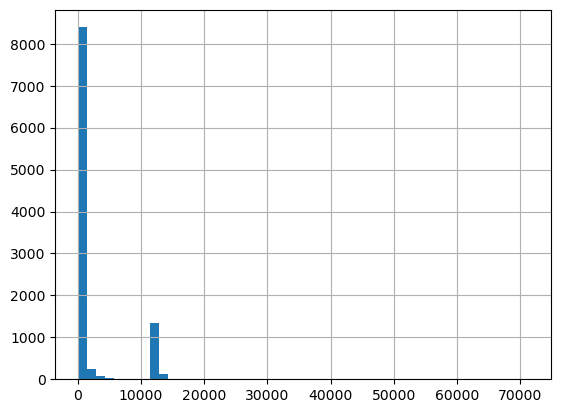

In [5]:
import matplotlib.pyplot as plt

df_final["Total Length of Fwd Packets"].hist(bins=50)
plt.show()


In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features for the model
features = ["Hour", "Port_Category", "Total Length of Fwd Packets"]

X = df_final[features]
y = df_final["is_attack"]   # for evaluation only

# Define transformers
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Port_Category"]),
        ("num", StandardScaler(), ["Hour", "Total Length of Fwd Packets"]),
    ]
)


In [7]:
from sklearn.ensemble import IsolationForest

# Build pipeline
iso_pipeline = Pipeline([
    ("prep", preprocess),
    ("iso", IsolationForest(
        n_estimators=150,
        contamination=0.03,   # we KNOW attacks ≈ 3%
        random_state=42
    ))
])

# Fit on entire dataset
iso_pipeline.fit(X)


,steps,"[('prep', ...), ('iso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
iso_scores = iso_pipeline.named_steps["iso"].decision_function(
    iso_pipeline.named_steps["prep"].transform(X)
)

# Convert scores to labels: -1 = anomaly, 1 = normal
iso_pred = iso_pipeline.named_steps["iso"].predict(
    iso_pipeline.named_steps["prep"].transform(X)
)

# Convert to boolean: True=attack, False=normal
iso_pred_bool = (iso_pred == -1)


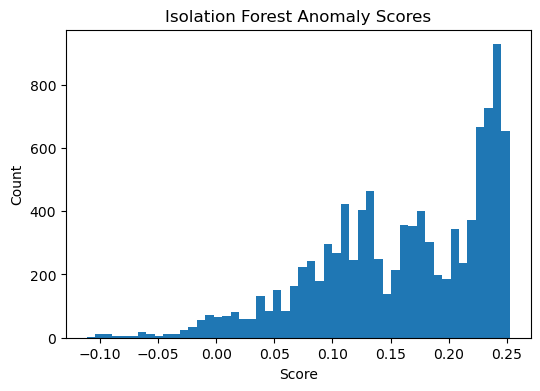

In [9]:
plt.figure(figsize=(6,4))
plt.hist(iso_scores, bins=50)
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y, iso_pred_bool))


              precision    recall  f1-score   support

       False       0.97      0.97      0.97     10000
        True       0.00      0.00      0.00       300

    accuracy                           0.94     10300
   macro avg       0.48      0.48      0.48     10300
weighted avg       0.94      0.94      0.94     10300



In [11]:
from sklearn.decomposition import PCA

# Transform data using the same preprocessing pipeline
X_transformed = preprocess.fit_transform(df_final[["Hour", "Port_Category", "Total Length of Fwd Packets"]])

# Reduce to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)

# Add PCA results to df_final for plotting
df_final["PC1"] = X_pca[:, 0]
df_final["PC2"] = X_pca[:, 1]


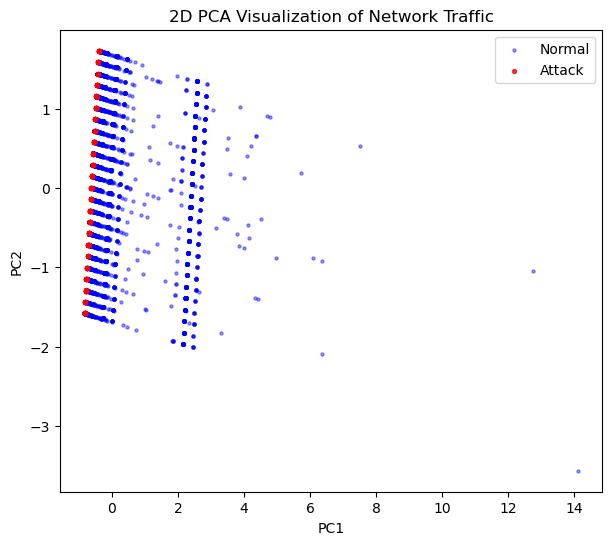

In [12]:
plt.figure(figsize=(7,6))

plt.scatter(
    df_final[df_final["is_attack"] == False]["PC1"],
    df_final[df_final["is_attack"] == False]["PC2"],
    c='blue',
    s=5,
    label="Normal",
    alpha=0.4
)

plt.scatter(
    df_final[df_final["is_attack"] == True]["PC1"],
    df_final[df_final["is_attack"] == True]["PC2"],
    c='red',
    s=8,
    label="Attack",
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Visualization of Network Traffic")
plt.legend()
plt.show()


In [ ]:
The 2D PCA visualization shows that most normal network flows form dense vertical bands, indicating similar behavior across the
limited feature space (Hour, Port_Category, and forward packet length). Attack flows appear in similar regions, with some scattered
points deviating from the main clusters, reflecting anomalous packet-size patterns but not forming a fully separate cluster due to
the simplicity of the selected features. Although PCA does not produce clear separation, the plot still highlights variability and
outliers, supporting the use of anomaly detection models like IsolationForest.